# **Speech Emotion Recognition Using Deep Learning**

## **Internship Project**

### **Created by:** Maira Asim

---

## Project Overview

This notebook focuses on recognizing human emotions from speech audio using audio signal processing and deep learning techniques.

## Project Objective

The goal of this project is to classify emotions from speech audio files. The model will learn patterns from audio features such as MFCCs, Mel Spectrograms, Chroma features, and other speech-related features.

## Planned Workflow

1. Import required libraries
2. Load and explore the dataset
3. Extract audio features
4. Apply data augmentation
5. Prepare training and testing data
6. Build a CNN-LSTM deep learning model
7. Train the model
8. Evaluate model performance
9. Test prediction on sample audio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import tensorflow as tf
import sklearn

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.21.0


## **Load RAVDESS Dataset**

The RAVDESS dataset contains speech audio files organized by actors.  
Each audio filename contains information about the emotion label.

For example:

`03-01-05-01-02-01-12.wav`

The third number represents the emotion:

- 01 = Neutral
- 02 = Calm
- 03 = Happy
- 04 = Sad
- 05 = Angry
- 06 = Fearful
- 07 = Disgust
- 08 = Surprised

In [3]:
from pathlib import Path

# Dataset path
ravdess_path = Path("../data/ravdess")

# Emotion labels
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Get all .wav files from all Actor folders
audio_files = list(ravdess_path.glob("Actor_*/*.wav"))

# Create dataframe
data = pd.DataFrame({
    "audio_path": [str(file) for file in audio_files],
    "emotion": [emotion_map[file.name.split("-")[2]] for file in audio_files]
})

print("Total audio files:", len(data))
data.head()

Total audio files: 1440


,audio_path,emotion
0,..\data\ravdess\Actor_01\03-01-01-01-01-01-01.wav,neutral
1,..\data\ravdess\Actor_01\03-01-01-01-01-02-01.wav,neutral
2,..\data\ravdess\Actor_01\03-01-01-01-02-01-01.wav,neutral
3,..\data\ravdess\Actor_01\03-01-01-01-02-02-01.wav,neutral
4,..\data\ravdess\Actor_01\03-01-02-01-01-01-01.wav,calm


## **Dataset Exploration**

Before training the model, we check how many audio samples are available for each emotion class.

In [4]:
# Count number of audio files for each emotion
emotion_counts = data["emotion"].value_counts()

print(emotion_counts)

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


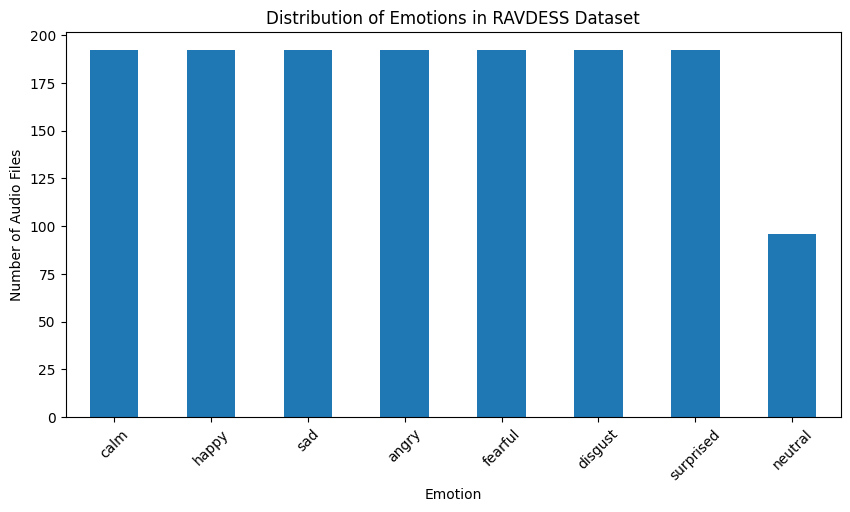

In [5]:
plt.figure(figsize=(10, 5))
data["emotion"].value_counts().plot(kind="bar")

plt.title("Distribution of Emotions in RAVDESS Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.show()

## **Audio Sample Visualization**

To better understand the dataset, we listen to one sample audio file and visualize its waveform.

In [6]:
from IPython.display import Audio

# Select one sample audio file
sample_audio_path = data["audio_path"].iloc[0]
sample_emotion = data["emotion"].iloc[0]

print("Sample emotion:", sample_emotion)
print("Sample audio path:", sample_audio_path)

# Play audio
Audio(sample_audio_path)

Sample emotion: neutral
Sample audio path: ..\data\ravdess\Actor_01\03-01-01-01-01-01-01.wav


Sample Rate: 48000
Audio Shape: (158558,)


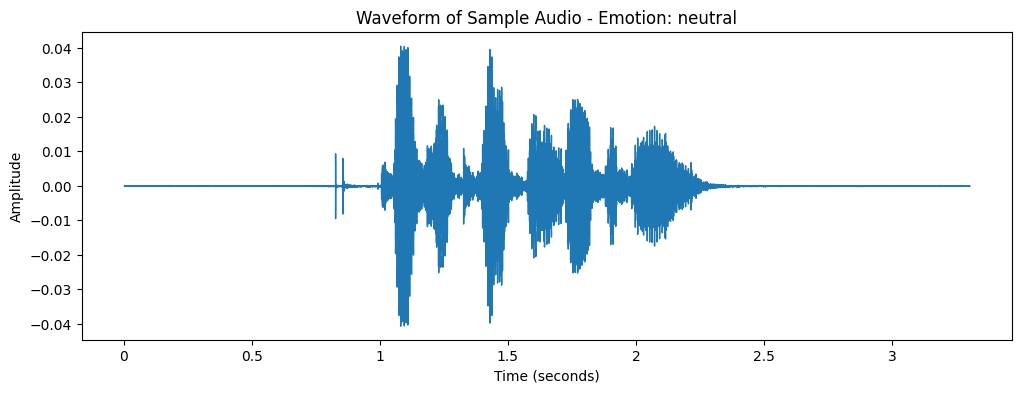

In [7]:
# Load the sample audio file
audio, sample_rate = librosa.load(sample_audio_path, sr=None)

print("Sample Rate:", sample_rate)
print("Audio Shape:", audio.shape)

# Plot waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)

plt.title(f"Waveform of Sample Audio - Emotion: {sample_emotion}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

### Observation

- The sample audio belongs to the **neutral** emotion class.  
- The waveform shows that the speech signal is mostly concentrated between approximately **1.0 and 2.3 seconds**, while the beginning and ending parts contain silence or very low amplitude.

- The sample rate is **48,000 Hz**, which means the audio was recorded with high quality.  
- The amplitude values show the strength of the sound signal over time. Higher peaks represent louder parts of the speech, while flat regions represent silence or low-energy parts.
- This visualization helps us understand the structure of the audio before extracting features such as MFCCs and Mel spectrograms.

## **Feature Extraction**

Audio files cannot be directly given to a machine learning model.  
Therefore, we extract numerical features from the audio signals.

In this project, we start with **MFCCs (Mel-Frequency Cepstral Coefficients)**, which are commonly used in speech and audio classification tasks.

In [8]:
def extract_mfcc(file_path, max_pad_len=174):
    """
    Extract MFCC features from an audio file.
    The output is padded or trimmed to make all samples the same size.
    """
    audio, sample_rate = librosa.load(file_path, sr=22050)
    
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )
    
    # Pad or trim MFCC to fixed length
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_pad_len]
    
    return mfcc

In [9]:
sample_mfcc = extract_mfcc(sample_audio_path)

print("MFCC shape:", sample_mfcc.shape)

MFCC shape: (40, 174)


### Output 

- MFCC feature extraction was tested on one sample audio file.
- Output shape: `(40, 174)`
- `40` represents the number of MFCC coefficients.
- `174` represents the fixed time length after padding/trimming.
- Fixed input size is required for training deep learning models.

## **Extract MFCC Features from All Audio Files**

In this step, MFCC features are extracted from every audio file in the dataset.  
The extracted features will be stored in `X`, and the emotion labels will be stored in `y`.

In [10]:
X = []
y = []

for index, row in data.iterrows():
    mfcc_features = extract_mfcc(row["audio_path"])
    X.append(mfcc_features)
    y.append(row["emotion"])

# Convert lists into NumPy arrays
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (1440, 40, 174)
Label shape: (1440,)


## **Label Encoding and Train-Test Split**

The emotion labels are currently in text form, such as `happy`, `sad`, and `angry`.

Deep learning models work with numbers, so the labels are converted into numerical format using label encoding.

After that, the dataset is divided into training and testing sets.

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Emotion classes:", label_encoder.classes_)

X_train shape: (1152, 40, 174, 1)
X_test shape: (288, 40, 174, 1)
y_train shape: (1152, 8)
y_test shape: (288, 8)
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## **CNN-LSTM Model Building**

A CNN-LSTM model is used for emotion classification.

- CNN layers learn important patterns from the MFCC feature maps.
- LSTM layers learn sequential/time-based information from the speech signal.
- Dense layers perform the final emotion classification.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.layers import Reshape, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Build CNN-LSTM model
model = Sequential()

# CNN block 1
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(40, 174, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# CNN block 2
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# Reshape CNN output for LSTM
model.add(Reshape((8, 42 * 64)))

# LSTM layer
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.4))

# Dense layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(y_categorical.shape[1], activation="softmax"))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 2688)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     1,442,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470,280 (5.61 MB)

 Trainable params: 1,470,088 (5.61 MB)

 Non-trainable params: 192 (768.00 B)

### Model Summary Observation

- The CNN-LSTM model was built successfully.
- The final output layer has `8` neurons, representing the 8 emotion classes.
- The model contains approximately `1.47 million` parameters.
- CNN layers extract spatial patterns from MFCC features.
- The LSTM layer learns sequential patterns from the extracted audio features.
- The GPU warning is not an error; the model will train using CPU.

## **Model Training**

The CNN-LSTM model is trained using the training dataset.

Validation data is used during training to monitor the model's performance on unseen data.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to improve training
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.1780 - loss: 2.0644 - val_accuracy: 0.1979 - val_loss: 1.9831 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.2457 - loss: 1.9114 - val_accuracy: 0.2153 - val_loss: 1.9028 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.3203 - loss: 1.8097 - val_accuracy: 0.2812 - val_loss: 1.7845 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.3064 - loss: 1.7734 - val_accuracy: 0.4201 - val_loss: 1.6752 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.3611 - loss: 1.6779 - val_accuracy: 0.3542 - val_loss: 1.6696 - learning_rate: 0.0010
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.3889 - loss: 1.6003 - val_accuracy: 0.3958 - val_loss: 1.6133 - learning_rate: 0.0010
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.4158 - loss: 1.5233 - 

## **Training Performance Visualization**

The training and validation accuracy/loss curves help us understand how well the model learned during training.

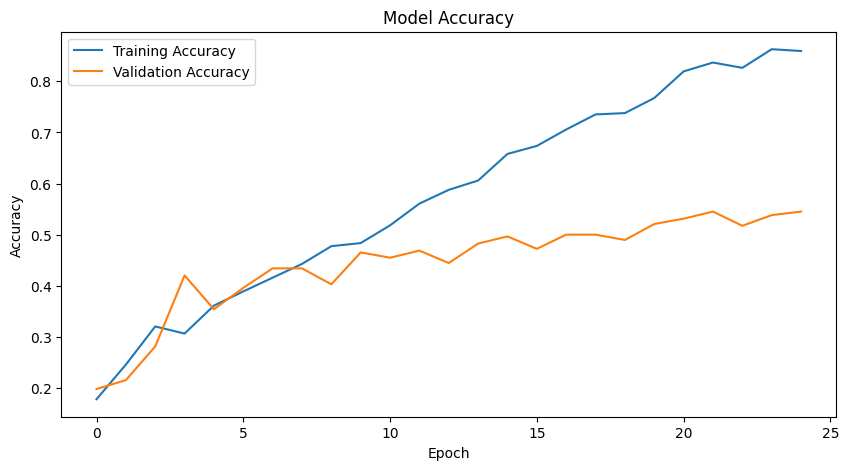

In [15]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Accuracy Graph Observation

- Training accuracy increases steadily during the epochs.
- Validation accuracy also improves, but remains lower than training accuracy.
- The final training accuracy is around **85%**, while validation accuracy is around **54%**.
- The gap between training and validation accuracy suggests **some overfitting**.
- The model is learning from the training data, but further tuning or data augmentation may improve generalization.

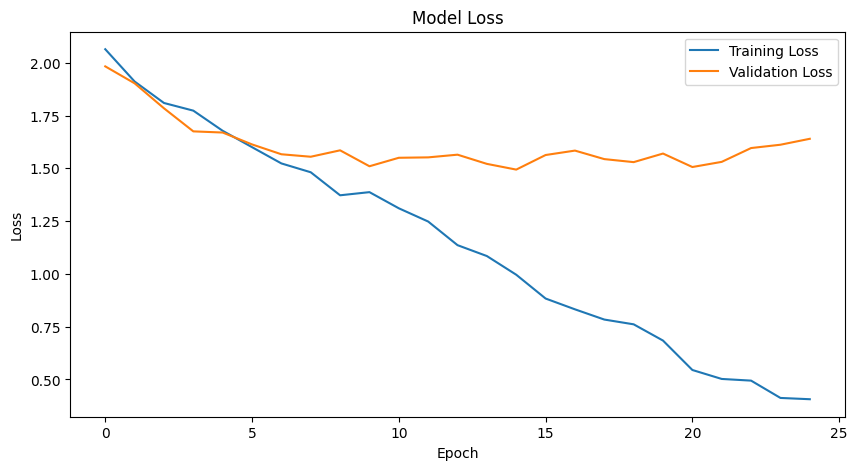

In [16]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Loss Graph Observation

- Training loss decreases steadily, showing that the model is learning from the training data.
- Validation loss decreases at first but then stays almost constant and slightly increases.
- This pattern suggests that the model starts to overfit after some epochs.
- The model performs well on training data, but its performance on unseen data can be improved with data augmentation, regularization, or model tuning.

## **Model Evaluation**

The trained CNN-LSTM model is evaluated on the test dataset to measure its performance on unseen audio samples.

In [19]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4965 - loss: 1.4941
Test Loss: 1.4940553903579712
Test Accuracy: 0.4965277910232544


### Evaluation Observation

- The model achieved a test accuracy of approximately **49.65%**.
- The test loss is approximately **1.49**.
- This shows that the model has learned useful speech emotion patterns, but its performance on unseen data is moderate.
- The result can be improved further using data augmentation, hyperparameter tuning, or additional audio features.

## **Classification Report**

The classification report shows precision, recall, and F1-score for each emotion class.

In [20]:
from sklearn.metrics import classification_report

# Predict classes for test data
y_pred = model.predict(X_test)

# Convert one-hot encoded labels back to class numbers
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_
)

print(report)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

       angry       0.51      0.62      0.56        39
        calm       0.43      0.79      0.56        38
     disgust       0.48      0.56      0.52        39
     fearful       0.71      0.44      0.54        39
       happy       0.60      0.16      0.25        38
     neutral       0.26      0.47      0.33        19
         sad       0.50      0.24      0.32        38
   surprised       0.68      0.68      0.68        38

    accuracy                           0.50       288
   macro avg       0.52      0.49      0.47       288
weighted avg       0.54      0.50      0.48       288



### Classification Report Observation

- The overall test accuracy is approximately **50%**.
- The model performs best on the **surprised** class, with an F1-score of **0.68**.
- The **angry**, **calm**, **disgust**, and **fearful** classes show moderate performance.
- The model performs weaker on **happy**, **neutral**, and **sad** emotions.
- The weighted average F1-score is **0.48**, showing that the model learned useful patterns but still needs improvement.
- Performance can be improved using more data, data augmentation, feature tuning, or a more optimized model architecture.

## **Confusion Matrix**

The confusion matrix shows how many samples were correctly and incorrectly classified for each emotion.

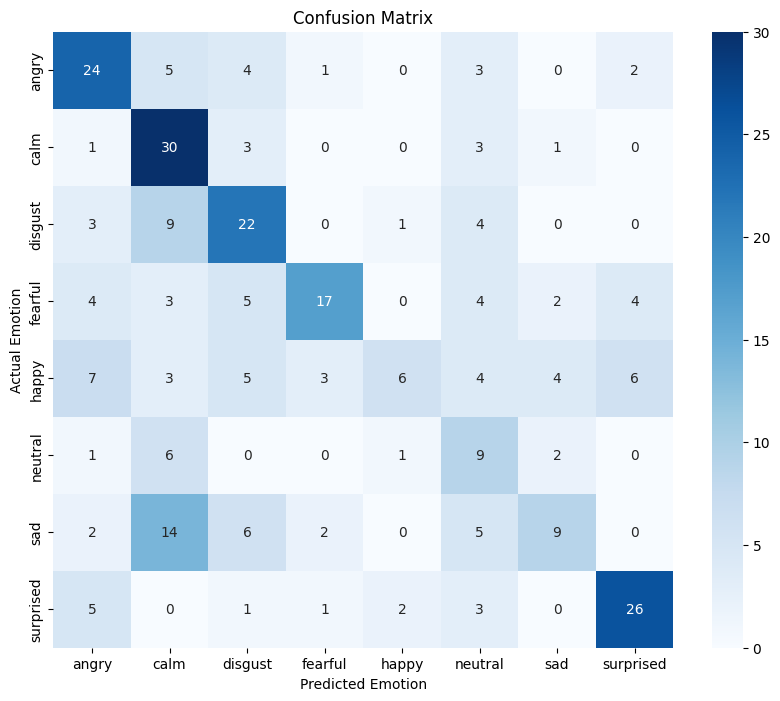

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

### Confusion Matrix Observation

- The model correctly predicts many samples from **angry**, **calm**, **disgust**, and **surprised** classes.
- **Surprised** and **calm** show strong performance compared to other emotions.
- The model struggles more with **happy**, **sad**, and **neutral** emotions.
- Some emotions are confused with similar-sounding classes, such as **sad** being predicted as **calm**.
- Overall, the confusion matrix shows that the model has learned emotion patterns, but further improvements are needed to reduce misclassification.

## **Save the Trained Model**

After training and evaluation, the trained CNN-LSTM model is saved for future use.  
This allows the model to be loaded later without training it again.

In [22]:
# Save the trained model
model.save("../models/speech_emotion_cnn_lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


## **Emotion Prediction on a Sample Audio File**

A prediction function is created to test the trained model on a single audio file.

The function:
- Extracts MFCC features from the audio
- Reshapes the features for the CNN-LSTM model
- Predicts the emotion class
- Returns the predicted emotion label

In [23]:
def predict_emotion(file_path):
    """
    Predict emotion from a single speech audio file.
    """
    # Extract MFCC features
    mfcc = extract_mfcc(file_path)
    
    # Reshape for model input
    mfcc = mfcc.reshape(1, 40, 174, 1)
    
    # Predict emotion probabilities
    prediction = model.predict(mfcc)
    
    # Get predicted class index
    predicted_index = np.argmax(prediction)
    
    # Convert index back to emotion label
    predicted_emotion = label_encoder.inverse_transform([predicted_index])[0]
    
    return predicted_emotion

In [24]:
# Test prediction on a sample audio file
test_audio_path = data["audio_path"].iloc[10]
actual_emotion = data["emotion"].iloc[10]

predicted_emotion = predict_emotion(test_audio_path)

print("Actual Emotion:", actual_emotion)
print("Predicted Emotion:", predicted_emotion)

Audio(test_audio_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Actual Emotion: calm
Predicted Emotion: calm


## **Prediction on Multiple Samples**

In [25]:
# Test predictions on multiple sample audio files
sample_indices = [10, 50, 100, 200, 300, 500, 700, 900, 1100, 1300]

for index in sample_indices:
    test_audio_path = data["audio_path"].iloc[index]
    actual_emotion = data["emotion"].iloc[index]
    predicted_emotion = predict_emotion(test_audio_path)
    
    print(f"Sample Index: {index}")
    print(f"Actual Emotion: {actual_emotion}")
    print(f"Predicted Emotion: {predicted_emotion}")
    print("-" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Sample Index: 10
Actual Emotion: calm
Predicted Emotion: calm
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Sample Index: 50
Actual Emotion: disgust
Predicted Emotion: disgust
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Sample Index: 100
Actual Emotion: fearful
Predicted Emotion: fearful
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Sample Index: 200
Actual Emotion: sad
Predicted Emotion: neutral
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Sample Index: 300
Actual Emotion: neutral
Predicted Emotion: neutral
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sample Index: 500
Actual Emotion: sad
Predicted Emotion: sad
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Sample Index: 700
Actual Emotion: fearful
Predicted Emotion: fearful
-------------------------

### Multiple Sample Prediction Observation

- The trained model was tested on 10 different audio samples.
- The model correctly predicted **8 out of 10** samples.
- Some incorrect predictions occurred, such as:
  - `sad` predicted as `neutral`
  - `sad` predicted as `calm`
- This shows that the model performs reasonably well on selected samples, but it still struggles with some similar emotional tones.
- Further improvements can be made using data augmentation, additional features, or model tuning.

## **Save Training Results**

The training accuracy and loss graphs are saved in the `results` folder for documentation and GitHub presentation.

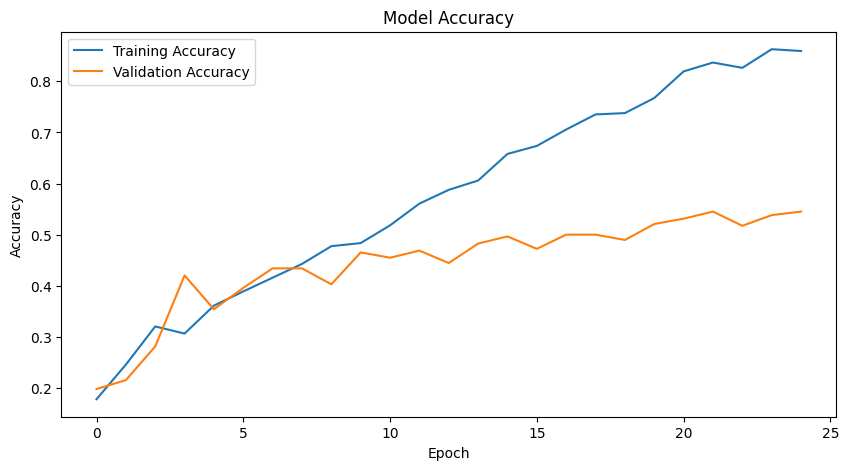

In [26]:
# Save accuracy graph
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../results/model_accuracy.png", bbox_inches="tight")
plt.show()

### Accuracy Graph Observation

- The accuracy graph shows that the model improved during training.
- Training accuracy increased steadily and reached around **85%**.
- Validation accuracy also improved but stayed around **54–55%**.
- The gap between training and validation accuracy suggests **overfitting**.
- This means the model learned the training data well, but needs improvement to perform better on unseen data.

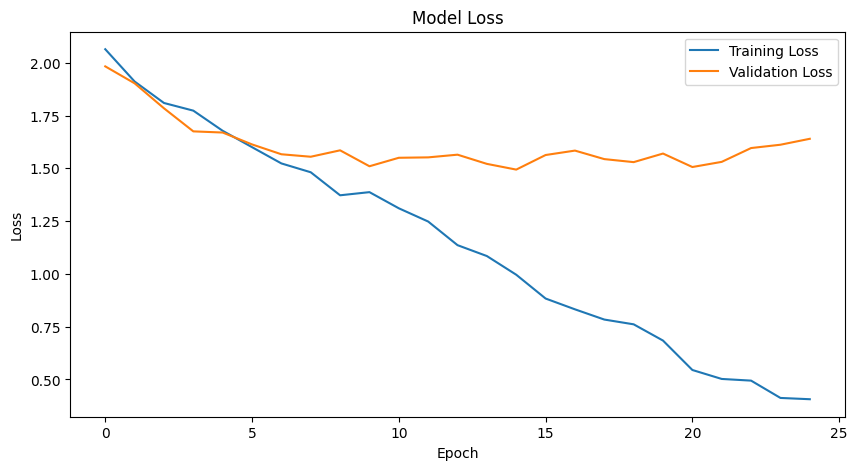

In [30]:
# Save loss graph
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../results/model_loss.png", bbox_inches="tight")
plt.show()

### Loss Graph Observation

- Training loss decreases steadily, showing that the model is learning from the training data.
- Validation loss decreases at first but then becomes almost stable and slightly increases.
- This indicates possible **overfitting** after some epochs.
- The model performs better on training data than on unseen validation data.

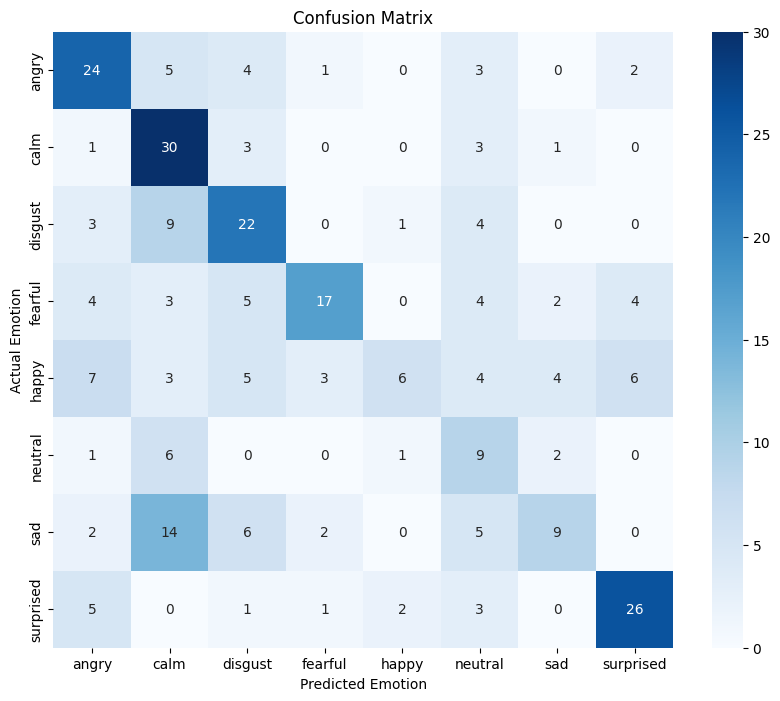

In [31]:
# Save confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.savefig("../results/confusion_matrix.png", bbox_inches="tight")
plt.show()

### Confusion Matrix Observation

- The model correctly predicts many samples from **calm**, **angry**, **disgust**, and **surprised** classes.
- **Calm** and **surprised** show stronger prediction performance.
- Some emotions are confused with similar-sounding classes, especially **sad**, **neutral**, and **happy**.
- Overall, the model has learned useful emotion patterns, but further tuning can improve classification accuracy.

In [32]:
# Save classification report
with open("../results/classification_report.txt", "w") as file:
    file.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!
